# 04 — Cleaning and network-wide fault flagging

Applies the Byrne (2023) quality rule (from `src/cleaning.py`) to every sensor Parquet. Rows are flagged, not deleted, so the full record is preserved for diagnostics. Cleaned Parquets are written to `data/processed/cleaned/`.

Three flags are produced: an implausible-range flag, the A/B disagreement flag, and a flatline flag for frozen readings, which the A/B test cannot see because a frozen unit's two channels agree perfectly.

Outputs: per-sensor cleaned Parquet files, `cleaning_summary.csv` (fault-candidate ranking by A/B disagreement rate), the A/B absolute-floor sensitivity table, and the coverage/threshold justification tables that underpin the daily-mean decision.

In [1]:
import sys
import re
from pathlib import Path

sys.path.append(str(Path.cwd().parent))
from src.config import *
from src.cleaning import clean_sensor
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def short_code(name):
    m = re.search(r"SL_?(\d+)", str(name).upper())
    return f"SL{int(m.group(1)):03d}" if m else str(name)

# Three contrasting sensors for a quick sanity check before the batch run
sl001 = pd.read_parquet(PROCESSED / "SL001_Sunnyview_Terrace.parquet")
sl026 = pd.read_parquet(PROCESSED / "SL026.parquet")
sl030 = pd.read_parquet(PROCESSED / "SL030.parquet")
print("SL001:", len(sl001), " SL026:", len(sl026), " SL030:", len(sl030))

SL001: 1038078  SL026: 972136  SL030: 12491


### Duplicate-timestamp check

Identifies whether any rows share a timestamp before relying on `drop_duplicates` inside `clean_sensor`.

In [2]:
def duplicate_report(df, name):
    full_dups = df.duplicated(keep=False).sum()
    ts_dups   = df.duplicated(subset=[DATE_COL], keep=False).sum()
    print(f"=== {name} ===")
    print(f"  total rows:            {len(df):,}")
    print(f"  fully identical rows:  {full_dups:,}")
    print(f"  duplicated timestamps: {ts_dups:,}\n")

for nm, d in [("SL001", sl001), ("SL026", sl026), ("SL030", sl030)]:
    duplicate_report(d, nm)

=== SL001 ===
  total rows:            1,038,078
  fully identical rows:  49
  duplicated timestamps: 49

=== SL026 ===
  total rows:            972,136
  fully identical rows:  0
  duplicated timestamps: 0

=== SL030 ===
  total rows:            12,491
  fully identical rows:  0
  duplicated timestamps: 0



### Choosing the absolute floor on the A/B difference

Byrne et al. (2023) apply the relative test alone. Cork's wintertime PM2.5 is
high enough for that to work, but Leeds air is much cleaner, and at a couple of
µg/m³ two healthy channels routinely differ by more than 50% through counting
noise alone. Barkjohn et al. (2021) pair the same relative test with an
absolute floor for exactly this reason.

The sweep below is the evidence for the value of `AB_ABS_MIN`. The high band is
the informative one: above 15 µg/m³ the ±5% test is tight and a small absolute
floor should barely touch it. A floor that collapses the low-band rate while
leaving the high-band rate intact is removing noise, not signal. A floor that
also cuts the high-band rate is removing evidence of real disagreement.

In [3]:
from src.cleaning import ab_rule_sweep

for name, df_raw in [("SL001", sl001), ("SL026", sl026), ("SL030", sl030)]:
    print(f"=== {name} ===")
    print(ab_rule_sweep(df_raw).to_string(index=False))
    print()

print(f"AB_ABS_MIN currently set to {AB_ABS_MIN} µg/m³ in config.py "
      f"(0.0 reproduces Byrne exactly)")

=== SL001 ===
 abs_floor_ugm3  pct_flagged_all  pct_flagged_low  pct_flagged_high
            0.0             57.8             38.6              91.6
            0.5             48.9             24.7              91.6
            1.0             45.2             18.9              91.4
            2.0             38.6             11.2              87.0
            5.0             26.0              1.9              68.6

=== SL026 ===
 abs_floor_ugm3  pct_flagged_all  pct_flagged_low  pct_flagged_high
            0.0             56.0             46.2              90.5
            0.5             45.6             32.9              90.5
            1.0             41.0             26.9              90.5
            2.0             30.3             14.8              85.0
            5.0              5.8              1.4              21.2

=== SL030 ===
 abs_floor_ugm3  pct_flagged_all  pct_flagged_low  pct_flagged_high
            0.0             33.1             13.5              94.3
    

### Sanity-check the rule on the three samples

`clean_sensor` is defined once in `src/cleaning.py` and imported here — the notebook never redefines it. The summary below confirms the flag rates and the drop in maximum PM2.5 look physically reasonable before the batch run.

In [4]:
for name, df_raw in [("SL001", sl001), ("SL026", sl026), ("SL030", sl030)]:
    cleaned, n_dups = clean_sensor(df_raw)
    n, clean_n = len(cleaned), cleaned["is_clean"].sum()
    print(f"=== {name} ===")
    print(f"  duplicates removed:    {n_dups:,}")
    print(f"  flagged implausible:   {cleaned['flag_implausible'].sum():,}")
    print(f"  flagged A/B disagree:  {cleaned['flag_ab'].sum():,}")
    print(f"  CLEAN rows:            {clean_n:,} / {n:,}  ({clean_n/n*100:.1f}%)")
    raw_max   = df_raw[PM_A].max()
    clean_max = cleaned.loc[cleaned["is_clean"], PM_A].max()
    print(f"  PM2.5 A max: raw {raw_max:.1f}  ->  clean {clean_max:.1f}\n")

=== SL001 ===
  duplicates removed:    38
  flagged implausible:   173,199
  flagged A/B disagree:  468,718
  CLEAN rows:            569,321 / 1,038,040  (54.8%)
  PM2.5 A max: raw 3402.1  ->  clean 731.3

=== SL026 ===
  duplicates removed:    0
  flagged implausible:   0
  flagged A/B disagree:  398,342
  CLEAN rows:            573,794 / 972,136  (59.0%)
  PM2.5 A max: raw 409.5  ->  clean 409.5

=== SL030 ===
  duplicates removed:    0
  flagged implausible:   0
  flagged A/B disagree:  3,159
  CLEAN rows:            9,332 / 12,491  (74.7%)
  PM2.5 A max: raw 72.6  ->  clean 40.4



### Network-wide cleaning

The cleaning rule is applied to every sensor Parquet. The summary table separates **high-band** A/B disagreement (above 15 µg/m³ — the genuine fault signal, because the ±5% tolerance is tight) from **low-band** disagreement (near-zero air is inherently noisy and both channels must be within ±50%). Sorting by the total flag rate without this split would unfairly rank sensors with many near-zero readings.

The flatline flag is reported alongside, split two ways. `n_flatline` counts
runs frozen at a non-zero value, which no working instrument produces.
`n_zero_run` counts runs frozen at exactly zero, which a PMS5003 in clean air
does produce legitimately; those rows are counted but not removed, because
flagging them would preferentially delete the cleanest readings in the network
and those are the ones that set the spatial baseline in NB07.

In [5]:
rows = []

# The sensor list comes from the NB02 inventory rather than a glob, so that
# network-level Parquets written by later notebooks can never be picked up as
# if they were sensors, whatever order the notebooks are run in.
inventory    = pd.read_csv(Tables / "sensor_inventory.csv")
sensor_files = [PROCESSED / f"{f}.parquet" for f in sorted(inventory["folder"])]
sensor_files = [p for p in sensor_files if p.exists()]
print(f"Cleaning {len(sensor_files)} study sensors")

for path in sensor_files:
    name = path.stem
    df_raw = pd.read_parquet(path)
    if PM_A not in df_raw.columns or PM_B not in df_raw.columns:
        print(f"  ! {name}: missing PM columns, skipped")
        continue

    cleaned, n_dups = clean_sensor(df_raw)
    cleaned.to_parquet(CLEANED / f"{name}.parquet", index=False)

    a, b   = cleaned[PM_A], cleaned[PM_B]
    higher = np.maximum(a, b)
    ab_high = (cleaned["flag_ab"] & (higher >  PM_BREAK)).sum()
    ab_low  = (cleaned["flag_ab"] & (higher <= PM_BREAK)).sum()

    rows.append({
        "sensor": name, "rows": len(cleaned), "duplicates": n_dups,
        "n_implausible":  int(cleaned["flag_implausible"].sum()),
        "n_ab_total":     int(cleaned["flag_ab"].sum()),
        "n_ab_highband":  int(ab_high),
        "n_ab_lowband":   int(ab_low),
        "n_highband":     int((higher > PM_BREAK).sum()),
        # The rate that matters: of the readings where the +/-5% test is
        # strict, what share failed it. The total flag rate is dominated by
        # clean-air counting noise and is not comparable between sensors.
        "pct_ab_highband": round(100 * ab_high / max((higher > PM_BREAK).sum(), 1), 1),
        "n_flatline":     int(cleaned["flag_flatline"].sum()),
        "n_zero_run":     int(cleaned["flag_zero_run"].sum()),
        "pct_flatline":   round(cleaned["flag_flatline"].mean() * 100, 2),
        "n_clean":        int(cleaned["is_clean"].sum()),
        "pct_clean":      round(cleaned["is_clean"].mean() * 100, 1),
        "pct_ab_flag":    round(cleaned["flag_ab"].mean() * 100, 1),
        "pm_a_max_raw":   round(df_raw[PM_A].max(), 1),
        "pm_a_max_clean": round(cleaned.loc[cleaned["is_clean"], PM_A].max(), 1),
    })
    print(f"  {name}: {len(cleaned):,} rows, {rows[-1]['pct_clean']}% clean, "
          f"{rows[-1]['pct_flatline']}% frozen")

Cleaning 47 study sensors
  SL001_Sunnyview_Terrace: 1,038,040 rows, 54.8% clean, 0.0% frozen
  SL003_Corn_Exchange_Cabinet: 575,919 rows, 68.1% clean, 0.0% frozen
  SL005_Kirkstall_Valley_Primary: 523,788 rows, 84.1% clean, 0.0% frozen
  SL006: 1,061,402 rows, 75.4% clean, 0.0% frozen
  SL007_Ninelands_Primary: 1,050,937 rows, 78.0% clean, 0.0% frozen
  SL008_Westgate_Primary: 771,477 rows, 66.7% clean, 0.0% frozen
  SL009: 168,047 rows, 75.4% clean, 0.0% frozen
  SL011: 832,625 rows, 65.1% clean, 0.0% frozen
  SL012_Morley: 934,506 rows, 86.5% clean, 0.0% frozen
  SL015_-_Garforth_Main_Street: 417,632 rows, 84.9% clean, 0.0% frozen
  SL016_Scholes_Main_Street: 739,970 rows, 85.6% clean, 0.0% frozen
  SL018_East_Ardsley_A650: 632,321 rows, 49.4% clean, 0.0% frozen
  SL019_Cornwall_Crescent_Rothwell: 735,362 rows, 86.7% clean, 0.0% frozen
  SL020: 641,465 rows, 80.9% clean, 0.0% frozen
  SL021_Kippax_Church_Lane: 591,314 rows, 64.6% clean, 0.0% frozen
  SL022_Church_Lane_Horsforth: 507

### Figure 1 — Fault-candidate ranking by A/B disagreement rate

`pct_ab_highband` is the honest fault signal: of the readings above 15 µg/m³,
where the ±5% tolerance is strict, what share failed the test. The total rate
`pct_ab_flag` is not comparable between sensors, because it is dominated by
clean-air counting noise and so mostly measures how clean a site is. The dots
on the chart show the total rate for the same sensors; where a bar is short and
its dot far to the right, that sensor's apparent fault rate is an artefact of
clean air.

Top fault candidates, ranked by the high-band rate:
                 sensor    rows  pct_ab_highband  n_highband  pct_ab_flag  pct_clean  pm_a_max_raw
SL018_East_Ardsley_A650  632321             97.9      201755         50.6       49.4        3398.8
 SL008_Westgate_Primary  771477             97.8      175755         33.3       66.7        3333.0
                  SL037  920665             97.7      786685         84.1       15.8        3407.9
                  SL030   12491             94.1        3029         25.3       74.7          72.6
                  SL011  832625             92.7      187920         34.9       65.1        1429.1
SL001_Sunnyview_Terrace 1038040             91.4      375711         45.2       54.8        3402.1
                  SL026  972136             90.5      214595         41.0       59.0         409.5
                  SL044  863374             90.5      284911         37.2       62.8        3394.8
                  SL062  661684             88.9      112

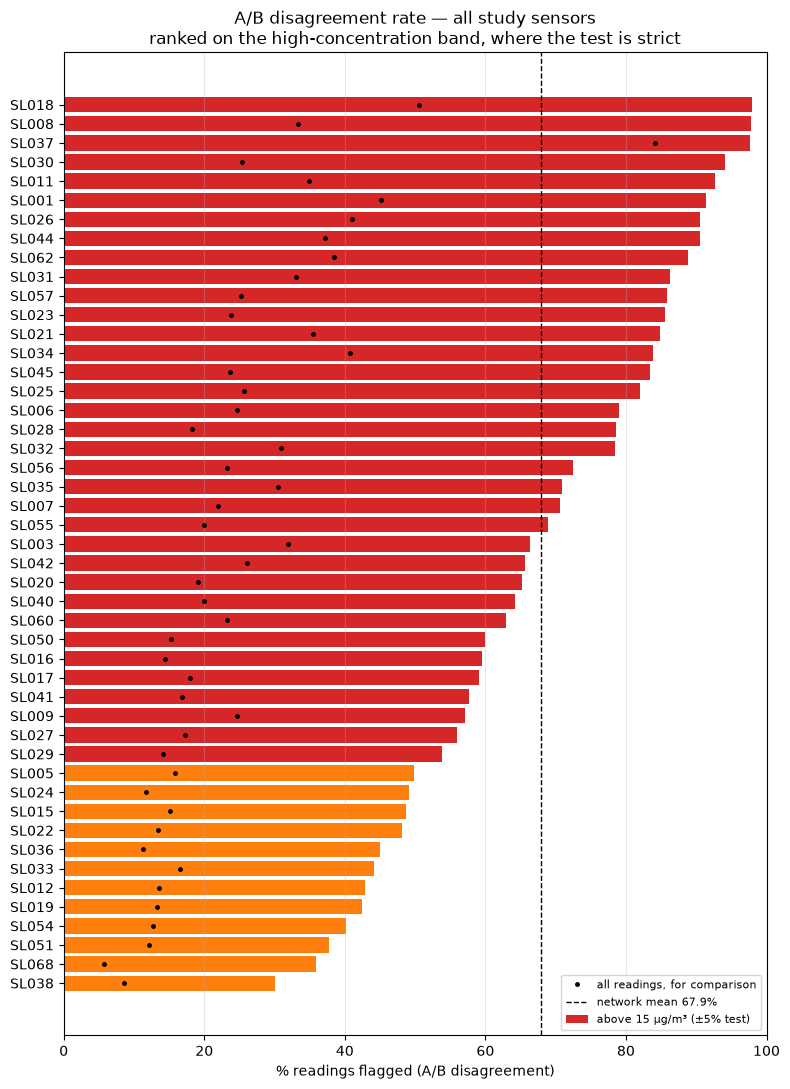

In [6]:
summary = pd.DataFrame(rows).sort_values("pct_ab_highband", ascending=False)
summary.to_csv(Tables / "cleaning_summary.csv", index=False)

print("Top fault candidates, ranked by the high-band rate:")
print(summary[["sensor", "rows", "pct_ab_highband", "n_highband",
               "pct_ab_flag", "pct_clean", "pm_a_max_raw"]].head(10).to_string(index=False))

# All sensors ranked by the high-band A/B rate. The total rate is plotted
# alongside to show how much of it is clean-air counting noise: the two
# orderings are quite different, and only the high-band one is comparable
# between sensors with different concentration distributions.
all_s = summary.copy()
all_s["label"] = all_s["sensor"].apply(short_code)

fig, ax = plt.subplots(figsize=(8, 11))
colors = ["tab:red" if v > 50 else ("tab:orange" if v > 20 else "tab:green")
          for v in all_s["pct_ab_highband"]]
ax.barh(all_s["label"], all_s["pct_ab_highband"], color=colors, height=0.8,
        label="above 15 µg/m³ (±5% test)")
ax.plot(all_s["pct_ab_flag"], all_s["label"], "k.", ms=5,
        label="all readings, for comparison")
ax.invert_yaxis()

net_mean = all_s["pct_ab_highband"].mean()
ax.axvline(net_mean, color="black", ls="--", lw=1,
           label=f"network mean {net_mean:.1f}%")
ax.set_xlabel("% readings flagged (A/B disagreement)")
ax.set_title("A/B disagreement rate — all study sensors\n"
             "ranked on the high-concentration band, where the test is strict")
ax.legend(fontsize=8)
ax.set_xlim(0, 100)
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig(Figures / "04_ab_fault_ranking.png", dpi=150, bbox_inches="tight")
plt.show()

### How much does the flatline flag actually remove?

The flag exists to cover the A/B test's blind spot, so it is worth stating what
it catches rather than leaving it as an unexamined rule.

In [7]:
flat = summary[["sensor", "rows", "n_flatline", "pct_flatline", "n_zero_run"]]
flat = flat.sort_values("pct_flatline", ascending=False)

print(f"network total frozen at a non-zero value: {summary['n_flatline'].sum():,} readings "
      f"({100 * summary['n_flatline'].sum() / summary['rows'].sum():.2f}% of all rows)")
print(f"network total frozen at zero (kept):      {summary['n_zero_run'].sum():,} readings")
print(f"sensors with any non-zero flatline: {(summary['n_flatline'] > 0).sum()} of {len(summary)}\n")
print(flat.head(10).to_string(index=False))

network total frozen at a non-zero value: 0 readings (0.00% of all rows)
network total frozen at zero (kept):      1,909,891 readings
sensors with any non-zero flatline: 0 of 47

                 sensor    rows  n_flatline  pct_flatline  n_zero_run
SL018_East_Ardsley_A650  632321           0           0.0       28153
 SL008_Westgate_Primary  771477           0           0.0       78424
                  SL037  920665           0           0.0        9596
                  SL030   12491           0           0.0        4449
                  SL011  832625           0           0.0       89250
SL001_Sunnyview_Terrace 1038040           0           0.0       68969
                  SL026  972136           0           0.0      115113
                  SL044  863374           0           0.0       69923
                  SL062  661684           0           0.0      100586
                  SL031   37125           0           0.0        6705


### Hourly coverage: how complete is each sensor's clean record?

Before deciding on daily vs hourly aggregation, the pipeline checks how many hours per sensor have sufficient clean readings. An hour is considered adequately sampled if at least `MIN_READ_PER_HOUR` (15) of the expected ~30 two-minute readings are present. This is the basis for the daily-mean decision: if most hours are inadequate, hourly resolution fails.

In [8]:
rows_cov = []
for path in sorted(CLEANED.glob("*.parquet")):
    name  = path.stem
    df    = pd.read_parquet(path)
    clean = df[df["is_clean"]].copy()
    if clean.empty:
        continue
    clean[DATE_COL] = pd.to_datetime(clean[DATE_COL])

    per_hour = clean.set_index(DATE_COL)[PM_A].resample("h").count()

    rows_cov.append({
        "sensor": name,
        "clean_rows": len(clean),
        "span_days": (clean[DATE_COL].max() - clean[DATE_COL].min()).days,
        "median_readings_per_hour": int(per_hour[per_hour > 0].median()),
        "pct_hours_well_covered": round(
            (per_hour >= MIN_READ_PER_HOUR).mean() * 100, 1),
        "pct_rows_with_RH": round(clean[RH_COL].notna().mean() * 100, 1),
    })

cov = pd.DataFrame(rows_cov).sort_values("pct_hours_well_covered", ascending=False)
cov.to_csv(Tables / "coverage_check.csv", index=False)
print(cov.to_string(index=False))
print(f"\nmedian % hours well-covered: {cov['pct_hours_well_covered'].median():.1f}%")
print(f"median % rows with RH:       {cov['pct_rows_with_RH'].median():.1f}%")
print(f"sensors with usable RH (>50%): {(cov['pct_rows_with_RH'] > 50).sum()} of {len(cov)}")

print(f"Network median hourly coverage: {cov['pct_hours_well_covered'].median():.1f}%  "
      f"({(cov['pct_hours_well_covered'] >= 70).sum()} of {len(cov)} sensors above 70%)")

                          sensor  clean_rows  span_days  median_readings_per_hour  pct_hours_well_covered  pct_rows_with_RH
      SL024_Wetherby_Town_Centre      906083       1615                        30                    81.3             100.0
                    SL012_Morley      808564       1495                        29                    79.6             100.0
         SL007_Ninelands_Primary      819552       1615                        29                    73.5              99.1
                           SL006      800191       1615                        29                    72.4              53.6
        SL027_-_SEE_Building_new      760151       1607                        27                    70.6             100.0
                           SL035      482113       1096                        26                    69.0             100.0
         SL001_Sunnyview_Terrace      569321       1204                        28                    68.4              88.9
SL019_Co

### Hourly coverage and threshold trade-off

The hourly coverage table saved above shows how many of each sensor's hours are adequately sampled (≥ `MIN_READ_PER_HOUR` = 15 readings). The sensitivity analysis below then quantifies what error that threshold introduces, and Figure 2 plots the trade-off directly.

### Sensitivity test: choosing `MIN_READ_PER_HOUR`

Is 15 readings the right bar for a valid hourly mean? The test finds hours where a sensor was fully online (≥28 of ~30 readings), so the true hourly mean is known. A contiguous block of T readings is then drawn from that hour and its mean compared to the truth — contiguous blocks mimic real dropouts, which is harsher than random subsampling. Every sensor in the network contributes, capped at 300 complete hours each so that long-lived sensors do not dominate.

sensors contributing: 47 of 47
hours tested per threshold: 3,995


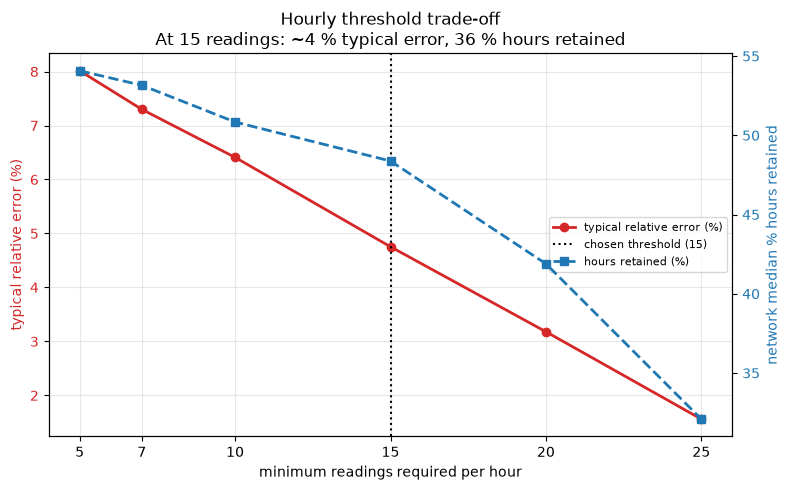

In [9]:
THRESHOLDS = [5, 7, 10, 15, 20, 25]
FULL_HOUR = 28          # an hour with >= this many readings counts as complete
PER_SENSOR_HOURS = 300  # cap per sensor so long-lived sensors don't dominate
MIN_TRUE_MEAN = 2.0     # skip near-zero hours where % error is meaningless

rng = np.random.default_rng(42)
abs_err = {t: [] for t in THRESHOLDS}
rel_err = {t: [] for t in THRESHOLDS}
coverage_rows = []
tested_per_sensor = {}

for path in sorted(CLEANED.glob("*.parquet")):
    df = pd.read_parquet(path, columns=[DATE_COL, PM_A, PM_B, "is_clean"])
    df = df[df["is_clean"]]
    if df.empty:
        continue

    ts = pd.to_datetime(df[DATE_COL], utc=True).dt.tz_localize(None)
    pm = ((df[PM_A] + df[PM_B]) / 2).to_numpy()
    order = np.argsort(ts.to_numpy())
    ts, pm = ts.to_numpy()[order], pm[order]
    hour = ts.astype("datetime64[h]")

    counts = pd.Series(1, index=hour).groupby(level=0).size()
    span = int((hour.max() - hour.min()) / np.timedelta64(1, "h")) + 1
    coverage_rows.append(
        {"sensor": path.stem,
         **{t: 100 * (counts >= t).sum() / span for t in THRESHOLDS}})

    full_hours = counts[counts >= FULL_HOUR].index.to_numpy()
    if len(full_hours) == 0:
        continue
    picked = rng.choice(full_hours, size=min(PER_SENSOR_HOURS, len(full_hours)), replace=False)
    picked_set = set(picked)

    n_tested = 0
    s = pd.Series(pm, index=hour)
    for h, vals in s.groupby(level=0):
        if h not in picked_set:
            continue
        v = vals.to_numpy()
        true_mean = v.mean()
        if true_mean < MIN_TRUE_MEAN:
            continue
        for t in THRESHOLDS:
            start = rng.integers(0, len(v) - t + 1)
            sub_mean = v[start:start + t].mean()
            abs_err[t].append(abs(sub_mean - true_mean))
            rel_err[t].append(abs(sub_mean - true_mean) / true_mean)
        n_tested += 1
    if n_tested:
        tested_per_sensor[path.stem] = n_tested

print(f"sensors contributing: {len(tested_per_sensor)} of {len(coverage_rows)}")
print(f"hours tested per threshold: {len(abs_err[THRESHOLDS[0]]):,}")

cov_median = pd.DataFrame(coverage_rows).set_index("sensor").median()

result = pd.DataFrame({
    "typical error (µg/m³)":        [np.median(abs_err[t]) for t in THRESHOLDS],
    "typical error (%)":             [100 * np.median(rel_err[t]) for t in THRESHOLDS],
    "worst-case error (%)":          [100 * np.percentile(rel_err[t], 90) for t in THRESHOLDS],
    "hours kept, network median (%)": [cov_median[t] for t in THRESHOLDS],
}, index=pd.Index(THRESHOLDS, name="readings required per hour")).round(1)

result.to_csv(Tables / "hourly_sensitivity.csv")

def highlight_chosen(row):
    style = "background-color: #fff3cd; font-weight: bold" if row.name == 15 else ""
    return [style] * len(row)

result.style.apply(highlight_chosen, axis=1).format(precision=1)

# Trade-off figure: error vs coverage as a function of threshold
fig, ax1 = plt.subplots(figsize=(8, 5))
ax2 = ax1.twinx()

errors   = [100 * np.median(rel_err[t]) for t in THRESHOLDS]
coverage = [float(cov_median[t]) for t in THRESHOLDS]

ax1.plot(THRESHOLDS, errors,   "o-",  color="tab:red",  lw=2, label="typical relative error (%)")
ax2.plot(THRESHOLDS, coverage, "s--", color="tab:blue", lw=2, label="hours retained (%)")

ax1.axvline(15, color="black", ls=":", lw=1.5, label="chosen threshold (15)")

ax1.set_xlabel("minimum readings required per hour")
ax1.set_ylabel("typical relative error (%)", color="tab:red")
ax2.set_ylabel("network median % hours retained", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:red")
ax2.tick_params(axis="y", labelcolor="tab:blue")
ax1.set_xticks(THRESHOLDS)
ax1.set_title("Hourly threshold trade-off\n"
              "At 15 readings: ~4 % typical error, 36 % hours retained")
ax1.grid(alpha=0.3)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=8, loc="center right")
fig.tight_layout()
plt.savefig(Figures / "04_hourly_threshold_tradeoff.png", dpi=150, bbox_inches="tight")
plt.show()

**How to read this.** Each row is one candidate threshold. *Typical error* is how far a partial-hour mean usually sits from the truth; *worst-case* is the 90th percentile. *Hours kept* is the network coverage that threshold allows.

The two halves pull in opposite directions. At the chosen value of **15** (highlighted) the typical error is ~4% and the worst case ~16%, for 36% network coverage. Relaxing to 5 readings recovers only ~52% of hours while letting worst-case error exceed 25% — so even the most permissive rule leaves half the network's hours missing. Hourly resolution fails in its best case, which is the quantitative basis for daily aggregation.

### Daily readings threshold: how many sensor-days survive?

The hourly sensitivity test above justifies `MIN_READ_PER_HOUR = 15`. This separate check justifies `MIN_READINGS_PER_DAY = 180` by showing how many total sensor-days the network retains at each daily reading threshold. A steep drop between 120 and 180 that barely changes between 180 and 240 marks 180 as the natural operating point.

In [10]:
THRESHOLDS_DAILY = [30, 60, 120, 180, 240, 360]

per_sensor_days = {}
grand = {t: 0 for t in THRESHOLDS_DAILY}

for path in sorted(CLEANED.glob("*.parquet")):
    name  = path.stem
    df    = pd.read_parquet(path)
    clean = df[df["is_clean"]].copy()
    if clean.empty:
        continue
    clean[DATE_COL] = pd.to_datetime(clean[DATE_COL])
    counts = clean.set_index(DATE_COL)[PM_A].resample("D").count()
    counts = counts[counts > 0]
    total  = len(counts)
    row = {t: int((counts >= t).sum()) for t in THRESHOLDS_DAILY}
    per_sensor_days[name] = (total, row)
    for t in THRESHOLDS_DAILY:
        grand[t] += row[t]

print("Network total valid sensor-days at each threshold:\n")
base = grand[THRESHOLDS_DAILY[0]]
for t in THRESHOLDS_DAILY:
    print(f"  >= {t:>3} readings/day: {grand[t]:>7,}  "
          f"({grand[t]/base*100:>5.1f}% of the >=30 baseline)")

print("\nSensors retaining >=100 valid days:")
for t in THRESHOLDS_DAILY:
    n = sum(1 for _, (_, row) in per_sensor_days.items() if row[t] >= 100)
    print(f"  >= {t:>3} readings/day: {n} sensors")

Network total valid sensor-days at each threshold:

  >=  30 readings/day:  35,554  (100.0% of the >=30 baseline)
  >=  60 readings/day:  35,042  ( 98.6% of the >=30 baseline)
  >= 120 readings/day:  34,138  ( 96.0% of the >=30 baseline)
  >= 180 readings/day:  33,116  ( 93.1% of the >=30 baseline)
  >= 240 readings/day:  31,886  ( 89.7% of the >=30 baseline)
  >= 360 readings/day:  28,454  ( 80.0% of the >=30 baseline)

Sensors retaining >=100 valid days:
  >=  30 readings/day: 44 sensors
  >=  60 readings/day: 43 sensors
  >= 120 readings/day: 43 sensors
  >= 180 readings/day: 43 sensors
  >= 240 readings/day: 43 sensors
  >= 360 readings/day: 43 sensors


### Figure 3 — A/B disagreement rate heatmap

Each row is one sensor (sorted worst-to-best by mean flag rate); each column is one calendar month. The colour shows the fraction of readings flagged for A/B disagreement that month. This makes three things immediately visible: which sensors are chronically bad (a fully dark row like SL037), when specific sensors deteriorated (a dark column appearing from a certain date), and which sensors recovered.

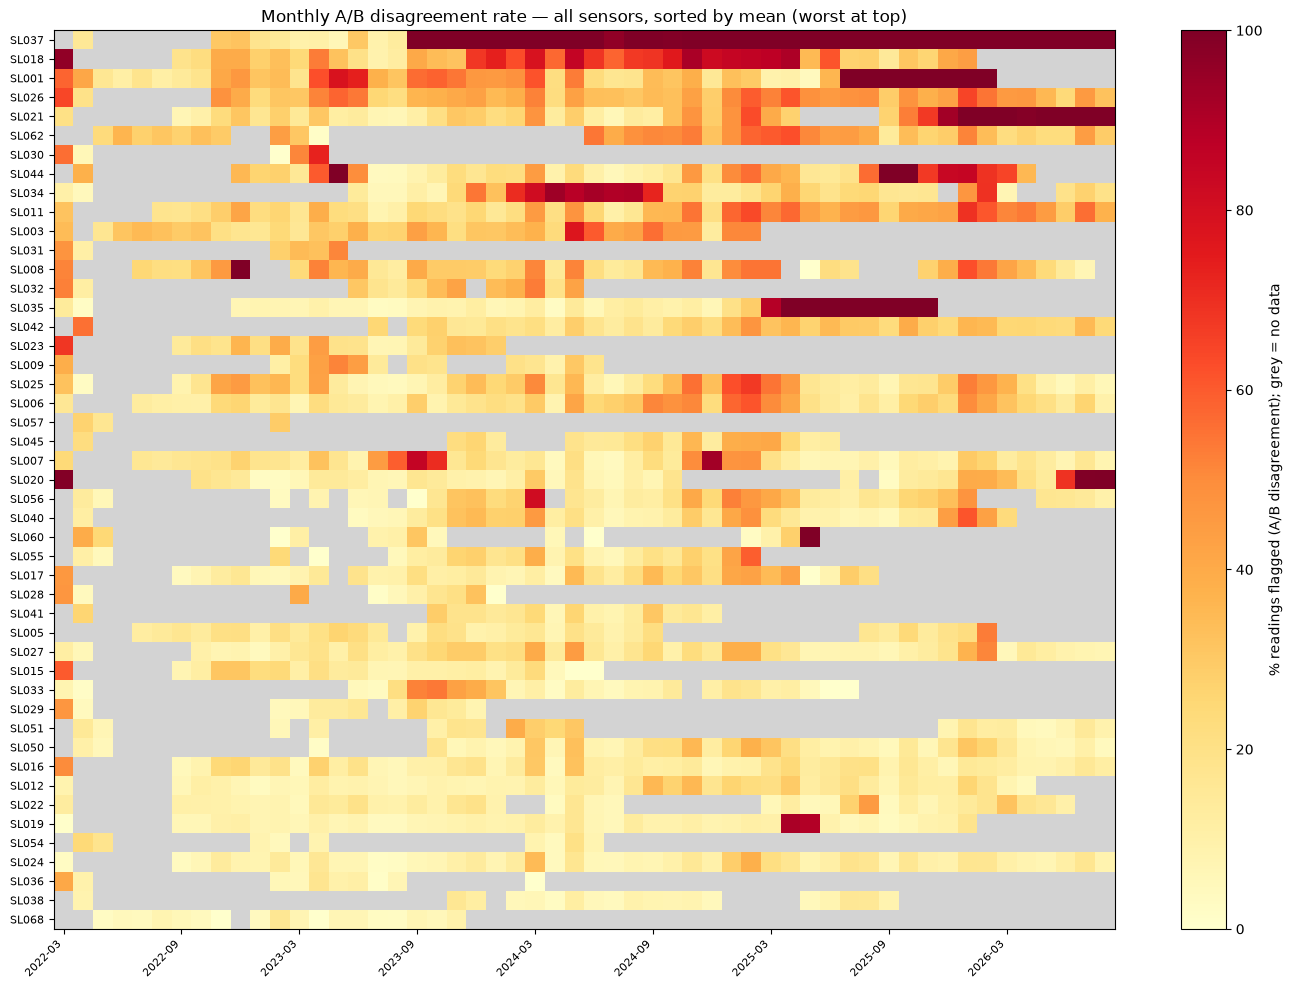

In [11]:
# Build monthly A/B flag rate for all sensors
frames = []
for sid in summary["sensor"]:
    path = CLEANED / f"{sid}.parquet"
    if not path.exists():
        continue
    df = pd.read_parquet(path, columns=[DATE_COL, "flag_ab"])
    df["sensor_id"] = sid
    df["timestamp"] = pd.to_datetime(df[DATE_COL], utc=True)
    frames.append(df[["sensor_id", "timestamp", "flag_ab"]])

df_all = pd.concat(frames, ignore_index=True)
df_all["month"] = (df_all["timestamp"].dt.tz_convert(LOCAL_TZ)
                    .dt.tz_localize(None).dt.to_period("M"))  # local calendar month already fixed above; drop tz explicitly to avoid a noisy pandas warning
df_all["code"]  = df_all["sensor_id"].map(short_code)

# Monthly mean flag rate per sensor — NaN where a sensor had no data that month
pivot = (df_all.groupby(["code", "month"])["flag_ab"]
         .mean()
         .unstack("month") * 100)
pivot = pivot.loc[pivot.mean(axis=1).sort_values(ascending=False).index]

months    = pivot.columns.to_timestamp()
tick_pos  = list(range(0, len(months), 6))
tick_lbls = [months[i].strftime("%Y-%m") for i in tick_pos]

cmap = plt.cm.YlOrRd.copy()
cmap.set_bad("lightgrey")  # NaN (no data that month) shown in grey, not white

fig, ax = plt.subplots(figsize=(14, 10))
im = ax.imshow(pivot.values, aspect="auto", cmap=cmap, vmin=0, vmax=100,
               interpolation="nearest")
fig.colorbar(im, ax=ax, label="% readings flagged (A/B disagreement); grey = no data")

ax.set_xticks(tick_pos)
ax.set_xticklabels(tick_lbls, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(len(pivot)))
ax.set_yticklabels(pivot.index, fontsize=8)
ax.set_title("Monthly A/B disagreement rate — all sensors, sorted by mean (worst at top)")
plt.tight_layout()
plt.savefig(Figures / "04_ab_monthly_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()